### 02. Raw Data Profiling

Simple profiling notebook for the **raw CSV layer**

identifying:
- nulls
- column types
- duplicate rows
- basic descriptive statistics
- columns that may need treatment before the Silver ingestion


In [7]:
# Parameters
from pathlib import Path

project_root = Path.cwd().parent

dataset_paths = {
    "acidentes":   str(project_root / "data" / "raw" / "renaest_dabertos_20230613-1" / "Acidentes_DadosAbertos_20230613.csv"),
    "localidade":  str(project_root / "data" / "raw" / "renaest_dabertos_20230613-1" / "Localidade_DadosAbertos_20230613.csv"),
    "tipoveiculo": str(project_root / "data" / "raw" / "renaest_dabertos_20230613-1" / "TipoVeiculo_DadosAbertos_20230613.csv"),
    "vitimas":     str(project_root / "data" / "raw" / "renaest_dabertos_20230613-1" / "Vitimas_DadosAbertos_20230613.csv"),
}

# Optional configs
sample_rows = None
output_dir = project_root / "outputs" / "profiling_raw"
save_outputs = True

print(dataset_paths)

{'acidentes': 'c:\\Users\\Diane\\git\\Lab01_PART1_97103\\data\\raw\\renaest_dabertos_20230613-1\\Acidentes_DadosAbertos_20230613.csv', 'localidade': 'c:\\Users\\Diane\\git\\Lab01_PART1_97103\\data\\raw\\renaest_dabertos_20230613-1\\Localidade_DadosAbertos_20230613.csv', 'tipoveiculo': 'c:\\Users\\Diane\\git\\Lab01_PART1_97103\\data\\raw\\renaest_dabertos_20230613-1\\TipoVeiculo_DadosAbertos_20230613.csv', 'vitimas': 'c:\\Users\\Diane\\git\\Lab01_PART1_97103\\data\\raw\\renaest_dabertos_20230613-1\\Vitimas_DadosAbertos_20230613.csv'}


## Imports

In [8]:
import sys
from pathlib import Path

import pandas as pd

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from profiling.raw_data_profiler import RawDataProfiler


## Run profiling

In [5]:
profiler = RawDataProfiler(
    dataset_paths=dataset_paths,
    output_dir=str(output_dir),
    sample_rows=sample_rows,
)

results = profiler.profile_all()
overview = profiler.create_overview_summary(results)
overview


NameError: name 'RawDataProfiler' is not defined

## Overview

In [5]:
overview

,dataset_name,rows,columns,duplicate_rows,columns_with_nulls,max_null_pct
0,acidentes,4754543,35,0,4,75.72
1,localidade,347014,12,0,0,0.00
2,tipoveiculo,5658317,4,0,0,0.00
3,vitimas,7560678,17,0,0,0.00


## Detailed profiling by dataset

In [6]:
for dataset_name, result in results.items():
    print("=" * 100)
    print(f"DATASET: {dataset_name.upper()}")
    print(f"Rows: {result.row_count:,}")
    print(f"Columns: {result.column_count:,}")
    print(f"Duplicate rows: {result.duplicates_count:,}")
    print("\nColumn types")
    display(result.column_types)
    print("\nNull summary")
    display(result.nulls)
    print("\nDescriptive statistics")
    display(result.descriptive_stats)


DATASET: ACIDENTES
Rows: 4,754,543
Columns: 35
Duplicate rows: 0

Column types


,column_name,pandas_dtype,inferred_type
0,num_acidente,object,probably_numeric
1,chv_localidade,object,string_or_categorical
2,data_acidente,object,probably_datetime
3,uf_acidente,object,string_or_categorical
4,ano_acidente,object,probably_numeric
5,mes_acidente,object,probably_numeric
6,mes_ano_acidente,object,probably_numeric
7,codigo_ibge,object,probably_numeric
8,dia_semana,object,string_or_categorical
9,fase_dia,object,string_or_categorical



Null summary


,column_name,null_count,null_pct,non_null_count,distinct_count
0,longitude_acidente,3599966,75.72,1154577,468469
1,latitude_acidente,3599837,75.71,1154706,467433
2,bairro_acidente,1910950,40.19,2843593,36398
3,end_acidente,151819,3.19,4602724,683833
4,ano_acidente,0,0.00,4754543,6
5,cep_acidente,0,0.00,4754543,26507
6,chv_localidade,0,0.00,4754543,200443
7,codigo_ibge,0,0.00,4754543,5465
8,cond_meteorologica,0,0.00,4754543,11
9,cond_pista,0,0.00,4754543,9



Descriptive statistics


...

,column_name,pandas_dtype,inferred_type
0,num_acidente,object,probably_numeric
1,chv_localidade,object,string_or_categorical
2,data_acidente,object,probably_datetime
3,uf_acidente,object,string_or_categorical
4,ano_acidente,object,probably_numeric
5,mes_acidente,object,probably_numeric
6,mes_ano_acidente,object,probably_numeric
7,faixa_idade,object,string_or_categorical
8,genero,object,string_or_categorical
9,tp_envolvido,object,string_or_categorical



Null summary


,column_name,null_count,null_pct,non_null_count,distinct_count
0,ano_acidente,0,0.0,7560678,6
1,chv_localidade,0,0.0,7560678,200443
2,data_acidente,0,0.0,7560678,1885
3,equip_seguranca,0,0.0,7560678,11
4,faixa_idade,0,0.0,7560678,15
5,genero,0,0.0,7560678,4
6,gravidade_lesao,0,0.0,7560678,6
7,ind_motorista,0,0.0,7560678,2
8,mes_acidente,0,0.0,7560678,12
9,mes_ano_acidente,0,0.0,7560678,62



Descriptive statistics


,column_name,count,mean,std,min,25%,50%,75%,max
0,num_acidente,7560678.0,2.430077e+06,1.402912e+06,1.0,1214899.0,2430527.5,3644935.75,4859253.0
1,chv_localidade,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,data_acidente,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,uf_acidente,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ano_acidente,7560678.0,2.020215e+03,1.419892e+00,2018.0,2019.0,2020.0,2021.00,2023.0
5,mes_acidente,7560678.0,6.545072e+00,3.483814e+00,1.0,3.0,7.0,10.00,12.0
6,mes_ano_acidente,7560678.0,6.747094e+04,3.483803e+04,12018.0,32022.0,72018.0,102018.00,122022.0
7,faixa_idade,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,genero,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,tp_envolvido,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Charts

CHARTS: ACIDENTES


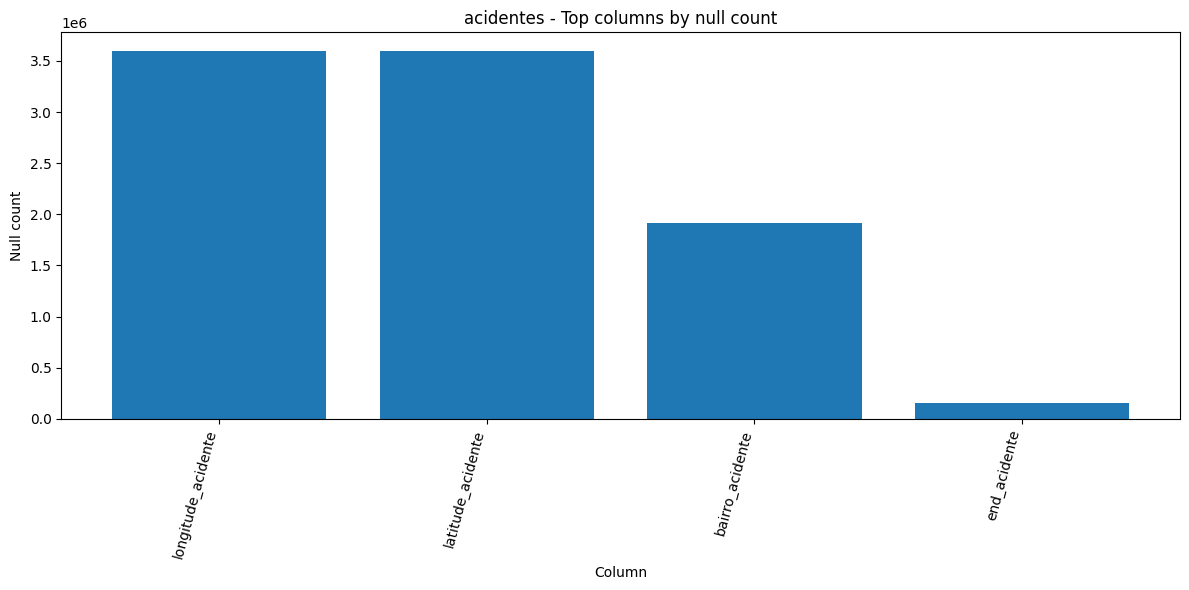

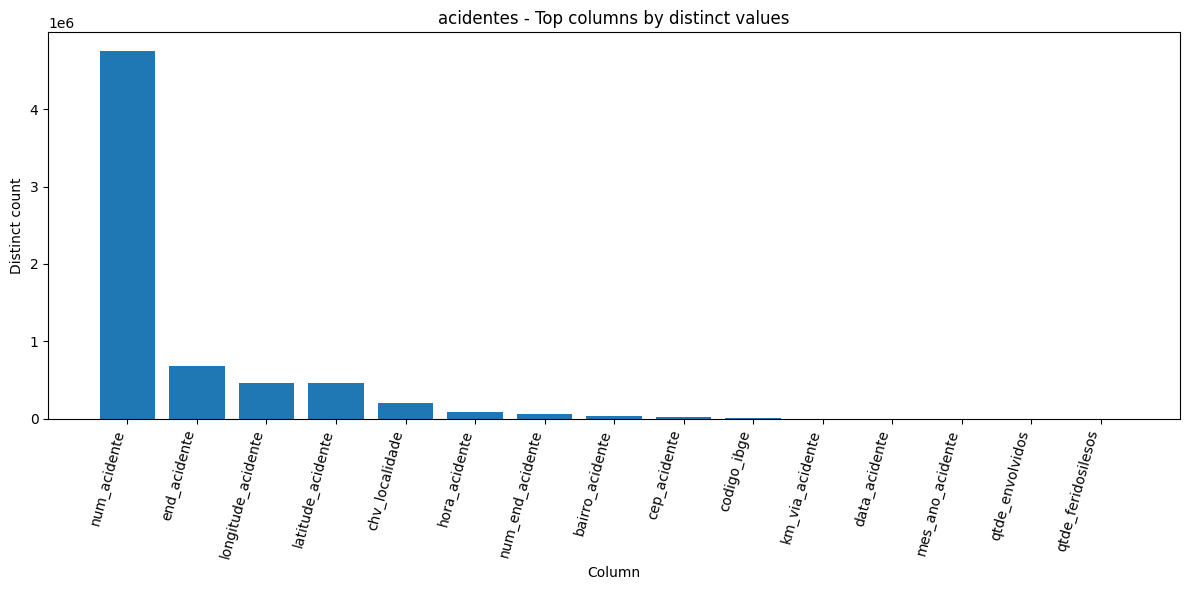

CHARTS: LOCALIDADE
[localidade] No nulls found.


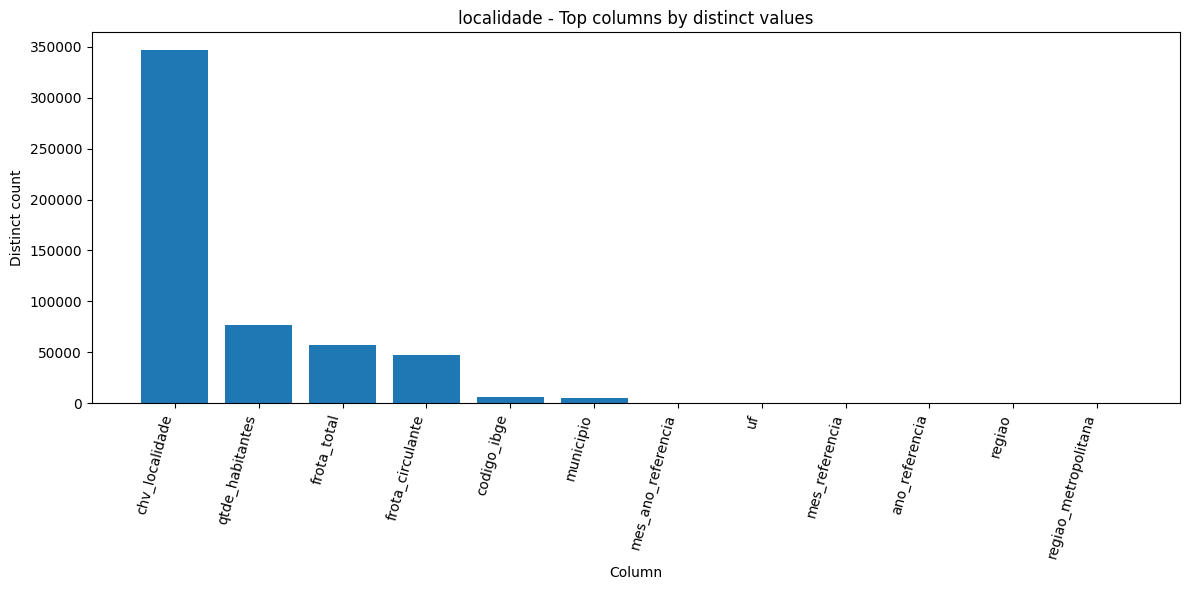

CHARTS: TIPOVEICULO
[tipoveiculo] No nulls found.


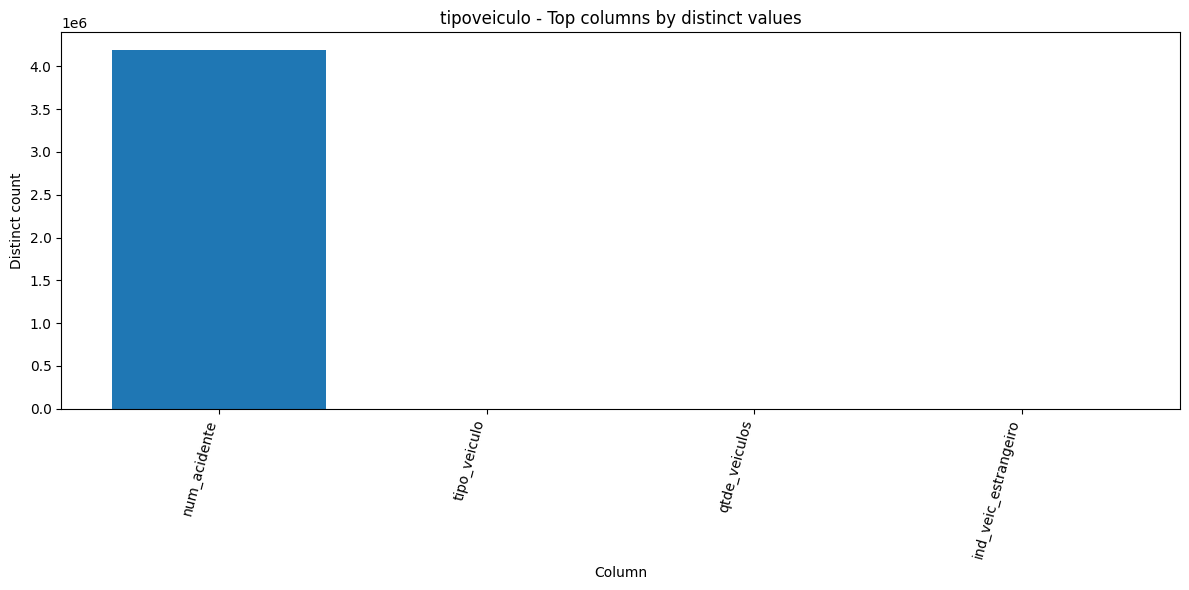

CHARTS: VITIMAS
[vitimas] No nulls found.


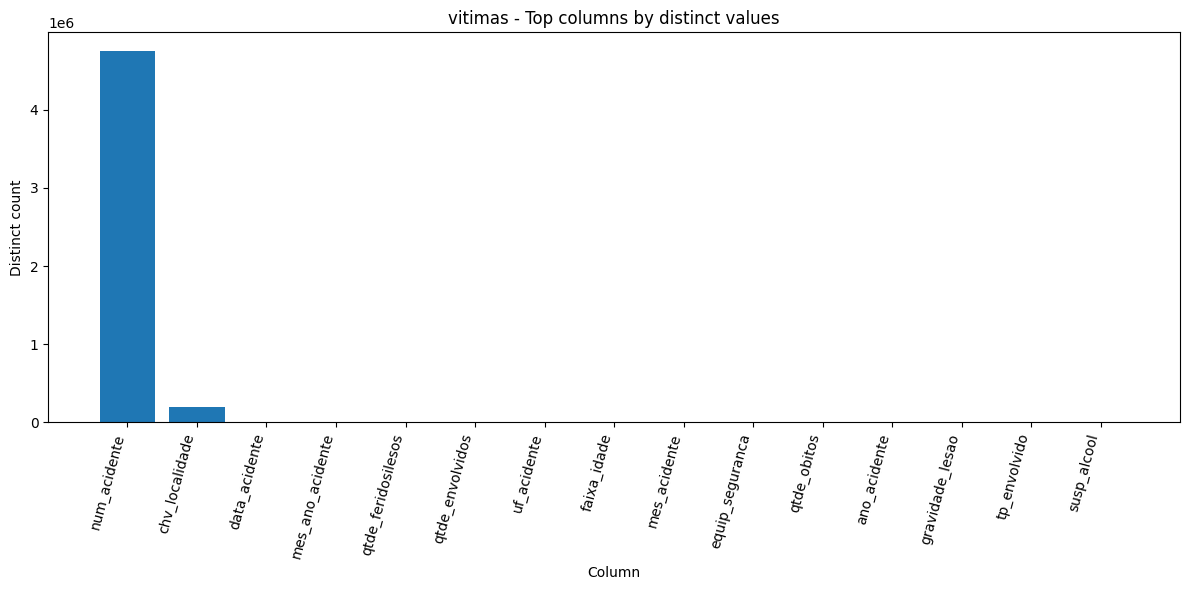

In [7]:
for dataset_name, result in results.items():
    print("=" * 100)
    print(f"CHARTS: {dataset_name.upper()}")
    profiler.plot_nulls(result)
    profiler.plot_distinct_counts(result)


## Optional export

In [ ]:
if save_outputs:
    profiler.export_results(results)

Profiling files exported to: c:\Users\Diane\git\Lab01_PART1_97103\outputs\profiling_raw


## Explore specific fields

In [9]:
df_acidentes = pd.read_csv(dataset_paths["acidentes"], delimiter=";")
df_localidade = pd.read_csv(dataset_paths["localidade"], delimiter=";")
df_tipoveiculo = pd.read_csv(dataset_paths["tipoveiculo"], delimiter=";")
df_vitimas = pd.read_csv(dataset_paths["vitimas"], delimiter=";")

C:\Users\Diane\AppData\Local\Temp\ipykernel_29176\1057341015.py:1: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df_acidentes = pd.read_csv(dataset_paths["acidentes"], delimiter=";")


In [16]:
df_acidentes.columns

Index(['num_acidente', 'chv_localidade', 'data_acidente', 'uf_acidente',
       'ano_acidente', 'mes_acidente', 'mes_ano_acidente', 'codigo_ibge',
       'dia_semana', 'fase_dia', 'tp_acidente', 'cond_meteorologica',
       'end_acidente', 'num_end_acidente', 'cep_acidente', 'bairro_acidente',
       'km_via_acidente', 'latitude_acidente', 'longitude_acidente',
       'hora_acidente', 'tp_rodovia', 'cond_pista', 'tp_cruzamento',
       'tp_pavimento', 'tp_curva', 'lim_velocidade', 'tp_pista',
       'ind_guardrail', 'ind_cantcentral', 'ind_acostamento', 'qtde_acidente',
       'qtde_acid_com_obitos', 'qtde_envolvidos', 'qtde_feridosilesos',
       'qtde_obitos'],
      dtype='object')

In [11]:
df_localidade.head()

,chv_localidade,ano_referencia,mes_referencia,mes_ano_referencia,regiao,uf,codigo_ibge,municipio,regiao_metropolitana,qtde_habitantes,frota_total,frota_circulante
0,AC1200013201801,2018,1,12018,NORTE,AC,1200013,ACRELANDIA,nao,14366,6552,4452
1,AC1200252201801,2018,1,12018,NORTE,AC,1200252,EPITACIOLANDIA,nao,17340,6014,4325
2,AC1200609201801,2018,1,12018,NORTE,AC,1200609,TARAUACA,nao,40024,4139,3138
3,AC1200401201801,2018,1,12018,NORTE,AC,1200401,RIO BRANCO,nao,383443,163579,116963
4,AC1200203201801,2018,1,12018,NORTE,AC,1200203,CRUZEIRO DO SUL,nao,82622,28867,20346


In [12]:
df_tipoveiculo.head()

,num_acidente,tipo_veiculo,ind_veic_estrangeiro,qtde_veiculos
0,14,NAO INFORMADO,NAO INFORMADO,1
1,117,NAO INFORMADO,NAO INFORMADO,1
2,118,NAO INFORMADO,NAO INFORMADO,1
3,119,NAO INFORMADO,NAO INFORMADO,1
4,144,NAO INFORMADO,NAO INFORMADO,1


In [13]:
df_vitimas.head()

,num_acidente,chv_localidade,data_acidente,uf_acidente,ano_acidente,mes_acidente,mes_ano_acidente,faixa_idade,genero,tp_envolvido,gravidade_lesao,equip_seguranca,ind_motorista,susp_alcool,qtde_envolvidos,qtde_feridosilesos,qtde_obitos
0,3830599,AC1200401201801,2018-01-11,AC,2018,1,12018,ENTRE 30 E 34 ANOS,MASCULINO,MOTORISTA,NAO INFORMADO,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0
1,4090868,AC1200401201801,2018-01-14,AC,2018,1,12018,ENTRE 45 E 49 ANOS,MASCULINO,MOTORISTA,NAO INFORMADO,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0
2,1753604,AC1200302201801,2018-01-02,AC,2018,1,12018,ENTRE 30 E 34 ANOS,MASCULINO,MOTORISTA,NAO INFORMADO,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0
3,2326310,AC1200401201801,2018-01-11,AC,2018,1,12018,ENTRE 75 E 79 ANOS,MASCULINO,MOTORISTA,NAO INFORMADO,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0
4,1670366,AC1200401201801,2018-01-10,AC,2018,1,12018,ENTRE 30 E 34 ANOS,FEMININO,MOTORISTA,NAO INFORMADO,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0


In [ ]:
df = df_acidentes
# df = df_localidade
# df = df_tipoveiculo
# df = df_vitimas

df_filter = df["ind_veic_estrangeiro"].value_counts(dropna=False)

print(df_filter)

ind_veic_estrangeiro
NAO INFORMADO    4683269
NAO               796120
DESCONHECIDO      177395
SIM                 1533
Name: count, dtype: int64
